In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

/home/archis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
signals_df = pd.read_csv('./signal_timings_data.csv')
traffic_df = pd.read_csv('./traffic_flow_data.csv')

In [4]:
signals_df.head()

,Intersection,Green_Light_Duration,Red_Light_Duration
0,Intersection_1,107,87
1,Intersection_2,41,47
2,Intersection_3,43,119
3,Intersection_4,111,115
4,Intersection_5,56,85


In [5]:
traffic_df.head()

,Intersection,Hour,Vehicle_Type,Vehicle_Count
0,Intersection_6,20,Car,357
1,Intersection_1,4,Public Transport,308
2,Intersection_4,16,Two-Wheeler,382
3,Intersection_4,3,Company Bus,207
4,Intersection_8,7,Public Transport,59


# Data Analysis

In [6]:
print(signals_df.isnull().sum())
print(traffic_df.isnull().sum())

Intersection            0
Green_Light_Duration    0
Red_Light_Duration      0
dtype: int64
Intersection     0
Hour             0
Vehicle_Type     0
Vehicle_Count    0
dtype: int64


In [7]:
traffic_df.groupby('Hour')['Vehicle_Count'].describe()

,count,mean,std,min,25%,50%,75%,max
Hour,,,,,,,,
0,11.0,340.181818,123.007169,109.0,267.00,342.0,441.00,483.0
1,9.0,249.222222,110.196163,69.0,231.00,266.0,316.00,412.0
2,6.0,263.500000,111.449989,129.0,189.25,248.0,338.25,418.0
3,14.0,323.857143,126.140860,98.0,209.00,378.5,434.50,463.0
4,13.0,266.461538,129.862501,109.0,146.00,217.0,405.00,467.0
5,8.0,237.125000,107.746312,74.0,154.75,268.0,311.00,382.0
6,8.0,285.000000,131.367532,121.0,192.25,287.0,352.25,497.0
7,16.0,272.937500,165.173230,56.0,123.00,291.5,415.75,499.0
8,10.0,230.300000,98.508939,134.0,145.75,188.5,330.25,365.0


In [8]:
def traffic_pattern(hour):
    if 7 <= hour <= 10:
        return 'Morning Peak'
    elif 17 <= hour <= 20:
        return 'Evening Peak'
    else:
        return 'Off-Peak'

traffic_df['Traffic Pattern'] = traffic_df['Hour'].apply(traffic_pattern)

In [9]:
traffic_df['Vehicle_Type'] = traffic_df['Vehicle_Type'].str.replace(' ', '_').str.replace('-', '_')

In [10]:
print("Total Vehicle Count per Traffic Timing:\n")
print(traffic_df.groupby('Traffic Pattern')['Vehicle_Count'].sum())

Total Vehicle Count per Traffic Timing:

Traffic Pattern
Evening Peak    12951
Morning Peak    12592
Off-Peak        40224
Name: Vehicle_Count, dtype: int64


### Traffic Volume Trends

In [ ]:
df = pd.merge(traffic_df, signals_df, on='Intersection', how='left')
df.head()

/tmp/ipykernel_5952/2031951594.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Hour', y='Vehicle_Count', data=df, estimator='sum', ci=None)


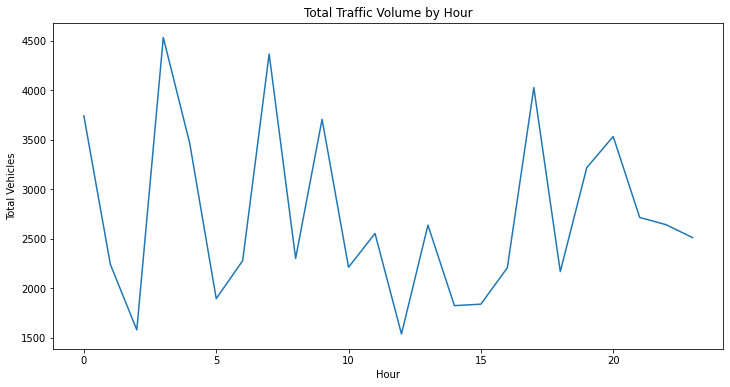

In [22]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Hour', y='Vehicle_Count', data=df, estimator='sum', ci=None)
plt.title('Total Traffic Volume by Hour')
plt.xlabel('Hour')
plt.ylabel('Total Vehicles')
plt.show()

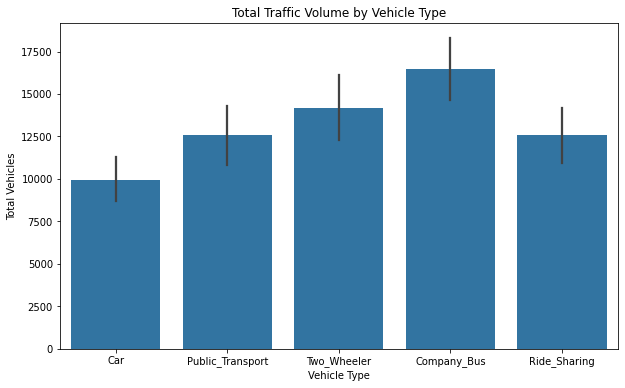

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Vehicle_Type', y='Vehicle_Count', data=df, estimator='sum')
plt.title('Total Traffic Volume by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Total Vehicles')
plt.show()

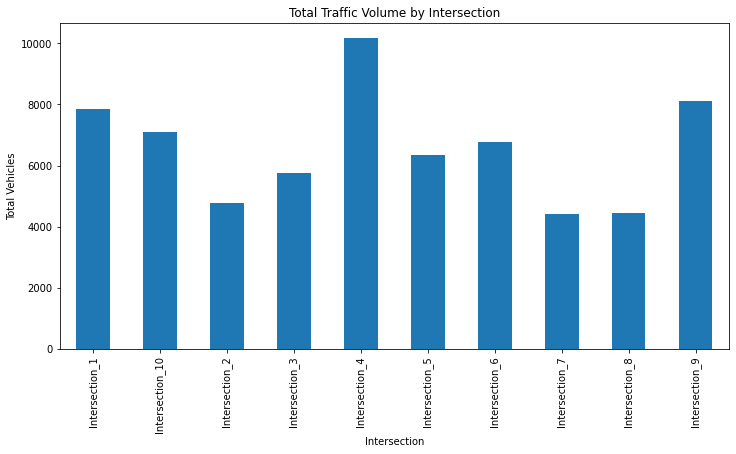

In [26]:
int_traffic = df.groupby('Intersection')['Vehicle_Count'].sum()
plt.figure(figsize=(12, 6))
int_traffic.plot(kind='bar')
plt.title('Total Traffic Volume by Intersection')
plt.ylabel('Total Vehicles')
plt.show()

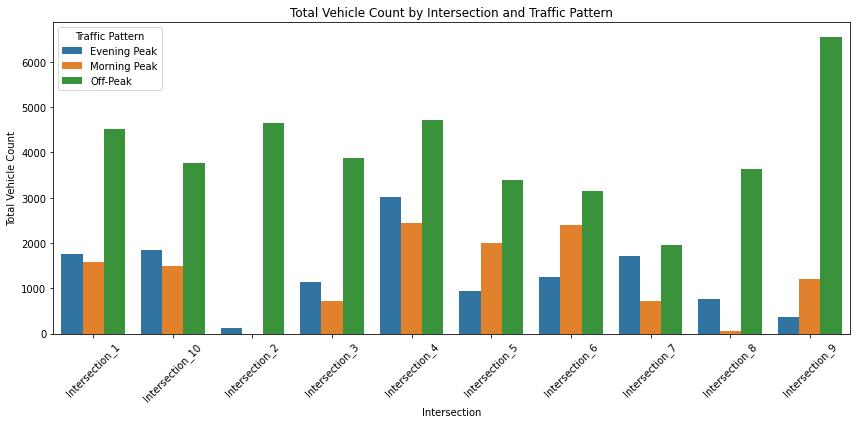

In [69]:
intersection_segment = traffic_df.groupby(['Intersection','Traffic Pattern'])['Vehicle_Count'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Intersection', y='Vehicle_Count', hue='Traffic Pattern', data=intersection_segment)
plt.title("Total Vehicle Count by Intersection and Traffic Pattern")
plt.xlabel("Intersection")
plt.ylabel("Total Vehicle Count")
plt.legend(title="Traffic Pattern")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Traffic Signal Timings

In [13]:
traffic_avg = df.groupby('Intersection').agg({
    'Vehicle_Count': 'mean',
    'Red_Light_Duration': 'first',   
    'Green_Light_Duration': 'first'
}).reset_index()

In [14]:
traffic_avg

,Intersection,Vehicle_Count,Red_Light_Duration,Green_Light_Duration
0,Intersection_1,302.500000,87,107
1,Intersection_10,296.000000,55,72
2,Intersection_2,281.411765,47,41
3,Intersection_3,239.416667,119,43
4,Intersection_4,274.891892,115,111
5,Intersection_5,287.863636,85,56
6,Intersection_6,294.956522,98,100
7,Intersection_7,259.529412,41,77
8,Intersection_8,234.631579,49,51
9,Intersection_9,261.612903,41,50


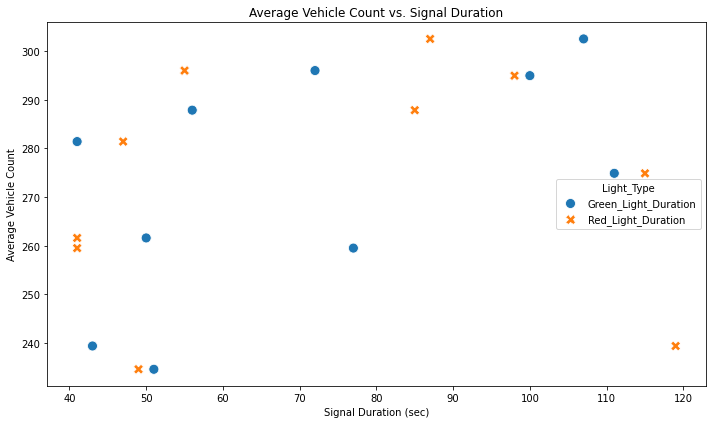

In [71]:
traffic_together = traffic_avg.melt(id_vars=["Vehicle_Count"],
                                  value_vars=["Green_Light_Duration", "Red_Light_Duration"],
                                  var_name="Light_Type",
                                  value_name="Duration")

plt.figure(figsize=(10, 6))
sns.scatterplot(x="Duration", y="Vehicle_Count", hue="Light_Type",
                style="Light_Type", s=100, data=traffic_together)
plt.title("Average Vehicle Count vs. Signal Duration")
plt.xlabel("Signal Duration (sec)")
plt.ylabel("Average Vehicle Count")
plt.tight_layout()
plt.show()


In [16]:
correlation = traffic_avg['Red_Light_Duration'].corr(traffic_avg['Vehicle_Count'])
print("Correlation:", correlation)

Correlation: 0.11529223239954266


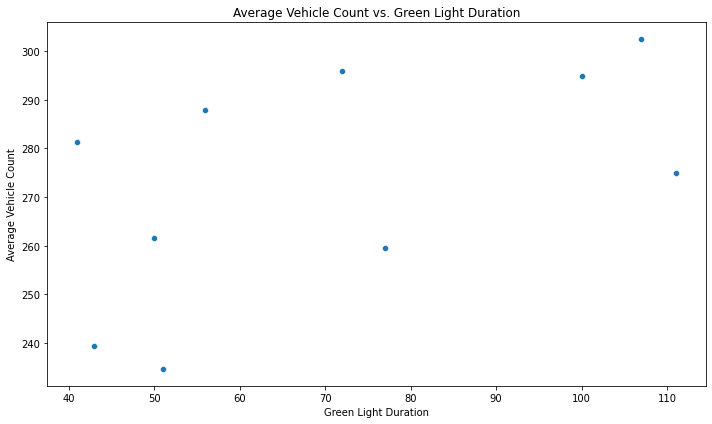

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Green_Light_Duration', y='Vehicle_Count', data=traffic_avg)
plt.title("Average Vehicle Count vs. Green Light Duration")
plt.xlabel("Green Light Duration")
plt.ylabel("Average Vehicle Count")
plt.tight_layout()
plt.show()

In [18]:
correlation = traffic_avg['Green_Light_Duration'].corr(traffic_avg['Vehicle_Count'])
print("Correlation:", correlation)

Correlation: 0.5535283789602179


In [32]:
peak = df[df['Traffic Pattern'].isin(['Morning Peak', 'Evening Peak'])]
peak_df = peak.groupby(['Intersection', 'Traffic Pattern']).agg({
    'Vehicle_Count': 'mean',
    'Green_Light_Duration': 'mean',
    'Red_Light_Duration': 'mean'
}).reset_index()

In [34]:
peak_df.head()

,Intersection,Traffic Pattern,Vehicle_Count,Green_Light_Duration,Red_Light_Duration
0,Intersection_1,Evening Peak,353.000000,107.0,87.0
1,Intersection_1,Morning Peak,224.714286,107.0,87.0
2,Intersection_10,Evening Peak,308.166667,72.0,55.0
3,Intersection_10,Morning Peak,297.000000,72.0,55.0
4,Intersection_2,Evening Peak,129.000000,41.0,47.0


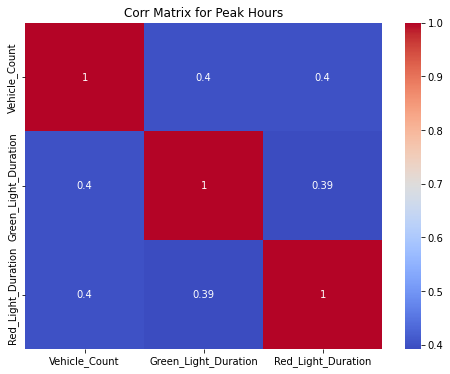

In [30]:
corr_matrix = peak_df[['Vehicle_Count', 'Green_Light_Duration', 'Red_Light_Duration']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Corr Matrix for Peak Hours')
plt.show()

### Traffic Efficiency Analysis

In [35]:
efficiency = df.groupby('Intersection').agg({
    'Vehicle_Count': 'sum',
    'Green_Light_Duration': 'mean',
    'Red_Light_Duration': 'mean'
}).reset_index()

In [36]:
efficiency['Green Pass'] = efficiency['Vehicle_Count']/efficiency['Green_Light_Duration']

In [37]:
efficiency.head()

,Intersection,Vehicle_Count,Green_Light_Duration,Red_Light_Duration,Green Pass
0,Intersection_1,7865,107.0,87.0,73.504673
1,Intersection_10,7104,72.0,55.0,98.666667
2,Intersection_2,4784,41.0,47.0,116.682927
3,Intersection_3,5746,43.0,119.0,133.627907
4,Intersection_4,10171,111.0,115.0,91.630631


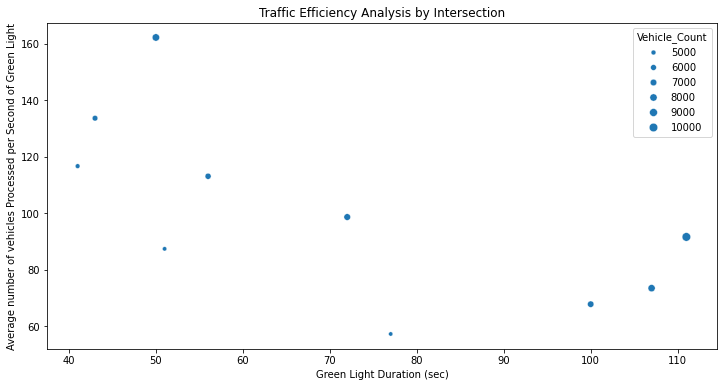

In [40]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Green_Light_Duration', y='Green Pass', 
                size='Vehicle_Count', data=efficiency)
plt.title('Traffic Efficiency Analysis by Intersection')
plt.xlabel('Green Light Duration (sec)')
plt.ylabel('Average number of vehicles Processed per Second of Green Light')
plt.show()

/tmp/ipykernel_5952/1024320600.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Intersection', y='Green Pass', data=efficiency, palette='viridis')
/tmp/ipykernel_5952/1024320600.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=45, ha='right')


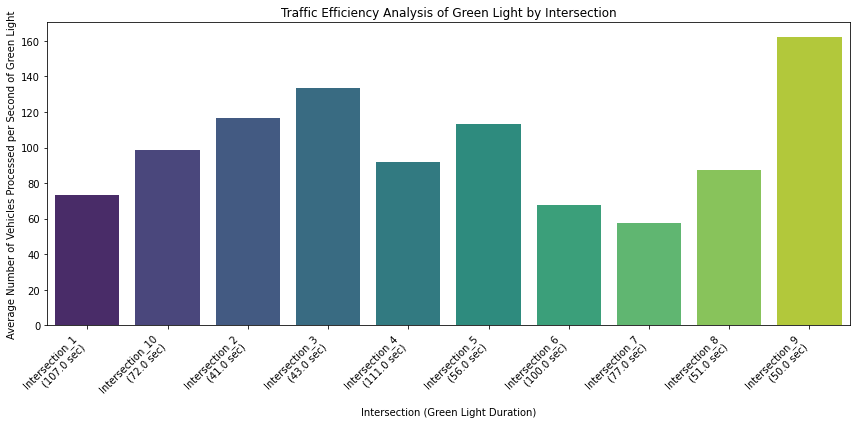

In [68]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Intersection', y='Green Pass', data=efficiency, palette='viridis')

plt.title('Traffic Efficiency Analysis of Green Light by Intersection')
plt.xlabel('Intersection (Green Light Duration)')
plt.ylabel('Average Number of Vehicles Processed per Second of Green Light')

tick_labels = []
for idx, row in efficiency.iterrows():
    label = f"{row['Intersection']}\n({row['Green_Light_Duration']} sec)"
    tick_labels.append(label)

ax.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [44]:
efficiency['Red Pass'] = efficiency['Vehicle_Count']/efficiency['Red_Light_Duration']

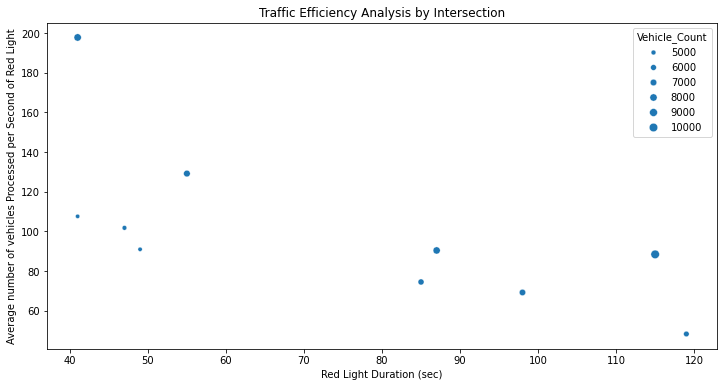

In [45]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Red_Light_Duration', y='Red Pass', 
                size='Vehicle_Count', data=efficiency)
plt.title('Traffic Efficiency Analysis by Intersection')
plt.xlabel('Red Light Duration (sec)')
plt.ylabel('Average number of vehicles Processed per Second of Red Light')
plt.show()

/tmp/ipykernel_5952/1028203077.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Intersection', y='Red Pass', data=efficiency, palette='plasma')
/tmp/ipykernel_5952/1028203077.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=45, ha='right')


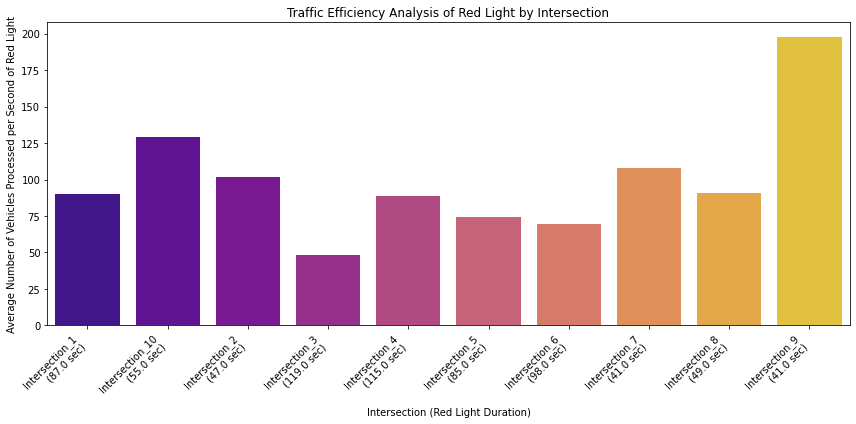

In [51]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Intersection', y='Red Pass', data=efficiency, palette='plasma')

plt.title('Traffic Inadequacy Analysis of Red Light by Intersection')
plt.xlabel('Intersection (Red Light Duration)')
plt.ylabel('Average Number of Vehicles Processed per Second of Red Light')

tick_labels = []
for idx, row in efficiency.iterrows():
    label = f"{row['Intersection']}\n({row['Red_Light_Duration']} sec)"
    tick_labels.append(label)

ax.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Optimization Strategies

### Adjusting Signal Timings

In [52]:
def compute_new_efficiency(row, g_factor, r_factor):
    return row['Green Pass'] * (g_factor / r_factor)

In [54]:
g_factors = np.linspace(1.0, 1.2, 5) 
r_factors = np.linspace(0.8, 1.0, 5) 

results = []

for g in g_factors:
    for r in r_factors:
        eff_mod = efficiency.copy()
        eff_mod['New_Efficiency'] = eff_mod.apply(lambda row: compute_new_efficiency(row, g, r), axis=1)
        avg_new_eff = eff_mod['New_Efficiency'].mean()
        results.append({'g_factor': g, 'r_factor': r, 'avg_new_efficiency': avg_new_eff})

In [55]:
results_df = pd.DataFrame(results)
results_df.head()

,g_factor,r_factor,avg_new_efficiency
0,1.0,0.80,125.244069
1,1.0,0.85,117.876771
2,1.0,0.90,111.328062
3,1.0,0.95,105.468690
4,1.0,1.00,100.195256


In [57]:
best = results_df.loc[results_df['avg_new_efficiency'].idxmax()]
print("Best combination: g_factor = {:.2f}, r_factor = {:.2f} with average new efficiency = {:.3f}".format(best['g_factor'], best['r_factor'], best['avg_new_efficiency']))

Best combination: g_factor = 1.20, r_factor = 0.80 with average new efficiency = 150.293


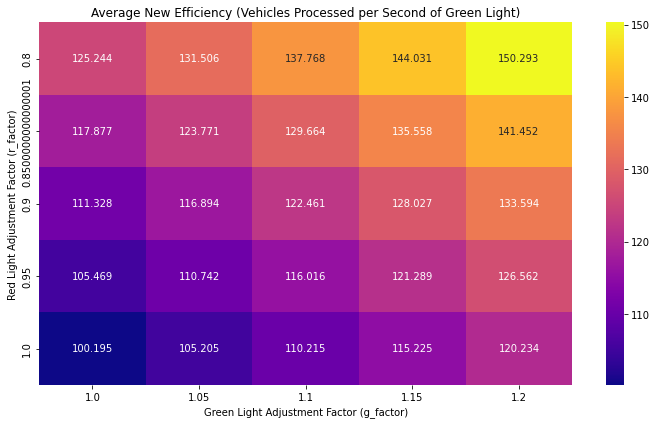

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_data = results_df.pivot(index="r_factor", columns="g_factor", values="avg_new_efficiency")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="plasma")
plt.title("Average New Efficiency (Vehicles Processed per Second of Green Light)")
plt.xlabel("Green Light Adjustment Factor (g_factor)")
plt.ylabel("Red Light Adjustment Factor (r_factor)")
plt.tight_layout()
plt.show()

### Adaptive Signals

In [65]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(0, 24)
np.random.seed(42)
vehicle_count = np.random.poisson(lam=50, size=24)
base_green_time = 30
base_red_time = 50
threshold_high = 60
threshold_low = 40

def adjust_timings(vc, base_green, base_red):
    if vc > threshold_high:
        return base_green * 1.2, base_red * 0.8
    elif vc < threshold_low:
        return base_green * 0.8, base_red * 1.2
    else:
        return base_green, base_red

adjusted_green_times = []
adjusted_red_times = []
for vc in vehicle_count:
    g, r = adjust_timings(vc, base_green_time, base_red_time)
    adjusted_green_times.append(g)
    adjusted_red_times.append(r)

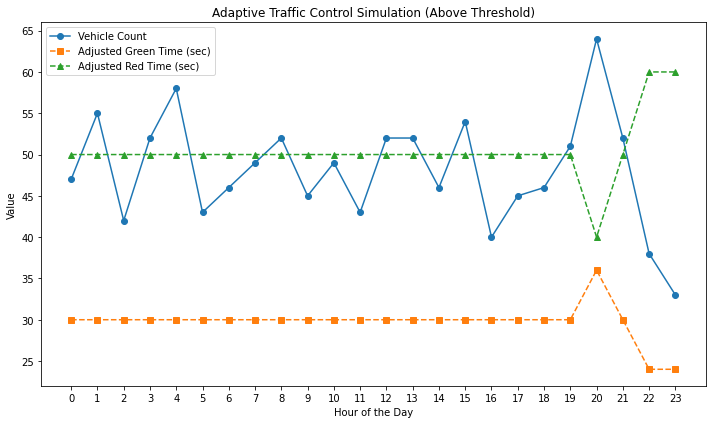

In [66]:
plt.figure(figsize=(10, 6))
plt.plot(hours, vehicle_count, label="Vehicle Count", marker="o")
plt.plot(hours, adjusted_green_times, label="Adjusted Green Time (sec)", marker="s", linestyle="--")
plt.plot(hours, adjusted_red_times, label="Adjusted Red Time (sec)", marker="^", linestyle="--")
plt.xlabel("Hour of the Day")
plt.ylabel("Value")
plt.title("Adaptive Traffic Control Simulation (Above Threshold)")
plt.legend()
plt.xticks(hours)
plt.tight_layout()
plt.show()